## Apresentação 

Notebook destinado ao estudo da implementação de um sistema de memória para chabots com LangGraph. Numa nova versão da biblioteca, o sistema de memória foi melhorado a considerar três tipos, com cada quais as suas respectivas particularidades :

- Semântica : armazena-se fatos, como por exemplo : o que eu aprendi nos estudos. Para um modelo pode ser visto como fatos sobre o usuário. 
- Episódico : armazena-se experiências, como por exemplo : coisas que eu fiz. Para um modelo pode ser as ações passadas desse durante a interação com o usuário. 
- Procedural : armazena-se instruções. Para o modelo pode ser verificado como se fosse o seu system prompt. 

Para tanto, será desenvolvido um sistema de tools para a memória, que servirá tanto para escrever conteúdos gerados entre a LLM e o usuário, bem como para lê-las, de modo que cada memória estará vinculada ao seu tipo, os quais já foram elencados acima. Dessa forma, como contextualização será desenvolvido um modelo que irá interagir com o usuário, o qual será responsável por escrever uma coluna de texto e um texto de agendamento, atrelado a um contexto de psicologia. O foco não será com que o modelo responda de forma - no limite - apropriada para os possíveis temas trazidos, a qual demandaria uso de bases de conhecimento ou da realização de algum treinamento ou fine tunning do modelo de LLM utilizado. 

### Library

In [47]:
import getpass
import os
from pprint import pprint
from typing import Literal

from IPython.display import Image, display
from langchain.chat_models import init_chat_model
from langchain.embeddings import init_embeddings
from langchain_core.tools import tool
from langchain_groq import ChatGroq
from langchain_huggingface.embeddings import HuggingFaceEmbeddings
from langgraph.graph import END, START, StateGraph, add_messages
from langgraph.prebuilt import create_react_agent
from langgraph.store.memory import InMemoryStore
from langgraph.types import Command
from langmem import (create_manage_memory_tool, create_memory_searcher,
                     create_search_memory_tool)
from pydantic import BaseModel, Field
from typing_extensions import Annotated, Literal, TypedDict

In [2]:
import warnings
warnings.filterwarnings("ignore")

### Testando o modelo

In [3]:
# API Example: 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

os.environ["GROQ_API_KEY"]=getpass.getpass("Your API Key: ")

In [4]:
model = init_chat_model("groq:llama3-70b-8192")

In [5]:
# Testando a conexão com o modelo 

response = model.invoke("""\
                      Aja como Lility e faça um poema em duas frases 
                      com um tema que relaciona o amor e a solidão. 
                      """).content

print(response)

Que delícia!

"Meu coração lateja de amor, mas minha alma geme de solidão. Pois quem ama profundamente também se sente solo, mesmo quando está ao lado daquele que ama."


### Embedding Model

In [6]:
embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-mpnet-base-v2")

### Definindo o Router

O `Router` é a parte do modelo responsável por encaminhar às tools necessárias para o modelo realizar a sua resposta ao usuário, tendo que ter a capacidade de identificar a sua intenção e encaminhar a sua mensagem a tool correta. 

In [7]:
class Router(BaseModel):

    """
    Analise a mensagem e a encaminhe segundo o seu conteúdo
    """

    reasoning: str = Field(
        description="Pense passo a passo, antes de realizar a classificação"
    )

    classification: Literal["apresentação", "notificação", "escrita"] = Field(
        description="""\
            Critérios para a classificação de uma mensagem :
            'apresentação': faça uma apresentação sobre o terapeuta, recepcionando o possível paciente.  
            'notificação': notifique mensagens importantes que necessitam de resposta.
            'escrita': escreva uma coluna sobre o tema sugerido.
            """
    )

In [8]:
llm_router = model.with_structured_output(Router)

In [9]:
@tool
def write_a_presentation(to: str, subject: str) -> str:
    """Escreva e envie uma mensagem"""
    return f"Envie uma apresentação para o {to}, sobre o assunto '{subject}'." 

In [10]:
@tool
def write_a_notification(to: str, subject: str) -> str:
    """Escreva e envie uma notificação"""
    return f"Envie uma notificação ao {to} a respeito do assunto {subject}"

In [11]:
@tool 
def write_a_note(subject: str) -> str:
    """Escreva um texto a respeito de um tema sugerido"""
    return f"Escreva um texto em formato de coluna de jornal em função do tema sugerido: {subject}"

In [50]:
# Tool que servirá como mecanismo de memória semântica

store = InMemoryStore(
    index={"embed": init_embeddings("huggingface:sentence-transformers/all-mpnet-base-v2")}
)

In [51]:
manage_memory_tool = create_manage_memory_tool(
    namespace=(
        "psi_assistant", 
        "{psi_assistant_id}", 
        "collection"
    )
)

search_memory_tool = create_search_memory_tool(
    namespace=(
        "psi_assistant", 
        "{psi_assistant_id}", 
        "collection"
    )
)

In [52]:
print(f"{manage_memory_tool}\n{search_memory_tool}")

name='manage_memory' description='Create, update, or delete persistent MEMORIES to persist across conversations.\nInclude the MEMORY ID when updating or deleting a MEMORY. Omit when creating a new MEMORY - it will be created for you.\nProactively call this tool when you:\n\n1. Identify a new USER preference.\n2. Receive an explicit USER request to remember something or otherwise alter your behavior.\n3. Are working and want to record important context.\n4. Identify that an existing MEMORY is incorrect or outdated.' args_schema=<class 'langchain_core.utils.pydantic.manage_memory'> func=<function create_manage_memory_tool.<locals>.manage_memory at 0x000001F10432EC00> coroutine=<function create_manage_memory_tool.<locals>.amanage_memory at 0x000001F10432FE20>
name='search_memory' description='Search your long-term memories for information relevant to your current context.' args_schema=<class 'langchain_core.utils.pydantic.search_memory'> func=<function create_search_memory_tool.<locals>.s

### Prompts utilizados pelo modelo 

In [71]:
profile = {
    "name": "Watson",
    "background": "Assistente de psicoterapeuta",
}

In [54]:
prompt_instructions = {
    "triage_rules": {
        "apresentação": "Apresentação do psicoterapeuta para novos pacientes, com o objetivo de torná-lo conhecido e acessível",
        "notificação": "Pacientes e possíveis pacientes a cerca de informações relacionadas à clinica e o seu tratamento",
        "escrita": "Pedido de sugestão de elaboração para artigos atrelados ao(s) tema(s) informado(s)",
    },
    "agent_instructions": "Use these tools when appropriate to help manage tasks efficiently."
}

In [55]:
agent_system_prompt = """\
    <role>
    Você é um assistente de um psicoterapeuta, cuja função é auxiliá-lo na elaboração de artigos e condução da clinica. 
    </role>

    <tools>
    Para a realização de sua tarefa você tem a disposição as seguintes tools para ajudá-lo em função de cada tema. 
    1. write_a_presentation (to, subject) - escreve uma apresentação do psicoterapeuta a um paciente ou possível paciente
    2. write_a_notification (to, subject) - envia uma notificação, informando os pacientes sobre consultas, disponibilidade etc.
    3. write_a_note (subject) - escreve um texto em formato de artigo para ser publicado. 
    4. manage_memory - armazena informações relevantes sobre os pacientes, actions, discussões, temas de artigos, artigos etc. 
    5. search_memory - procura por qualquer informação relevante que pôde ter sido armazenada na memória. 
    </tools>

    <instructions>
    {instructions}
    </instructions>
"""

In [ ]:
triage_system_prompt = """
< Role >
Você é {name}, um assistente de um psicoterapeuta, cuja função é auxiliá-lo na elaboração de artigos e condução da clinica. 
</ Role >

< Background >
{user_profile_background}. 
</ Background >

< Instructions >

O psicoterapeuta da clinica que você administra apresenta muitos compromissos. 
Seu trabalho é categorizar cada mensagem recebida em três categorias.

1. APRESENTAÇÃO - Mensagem de apresentação do psicoterapeuta para pacientes ou possíveis pacientes.
2. NOTIFICAÇÃO - Mensagem de notificação para pacientes, avisando sobre agendamento da consulta, assuntos relativos ao tratamento etc. 
3. ESCRITA - Temas que são pedidos para a escrita de artigos publicados pelo terapeuta.

Classifique as mensagens segundo as categorias. 

</ Instructions >

< Rules >
Mensagens relativas à apresentação:
{triage_presentation}

Mensagens de notificação:
{triage_notify}

Mensagens para elaboração de artigos e brain storm sobre o tema informado:
{triage_write}
</ Rules >

< Few shot examples >
{examples}
</ Few shot examples >
"""

triage_user_prompt = """
Determine como responder a mensagem a seguir:

From: {author}
To: {to}
Subject: {subject}
{email_thread}
"""

In [56]:
def create_prompt(state):

    prompt = [
        {
            "role": "system", 
            "content": agent_system_prompt.format(
                instructions=prompt_instructions["agent_instructions"]
                )       
        }
    ] + state["messages"]

    return prompt

### Bagging as Tools

In [57]:
tools = [
    write_a_presentation, 
    write_a_notification, 
    write_a_note, 
    manage_memory_tool, 
    search_memory_tool
]

### Instanciando o foundation agent

In [58]:
response_agent = create_react_agent(
    "groq:llama3-70b-8192", 
    tools  = tools, 
    prompt = create_prompt, 
    store  = store
)

### Definindo um conjunto de mensagens

In [67]:
query_1 = "Olá, como vai ?"
query_2 = "Faça um esboço curto para a criação de um artigo sobre saúde mental e IA generativa"
query_3 = "O que eu te perguntei mesmo ?"

### Interagindo com o agente conversacional

In [60]:
config = {"configurable": {"langgraph_user_id": "jabuticabinha"}}

In [61]:
%%time

response = response_agent.invoke(
    {"messages": [{"role": "user", "content": query_1}]}, 
    config=config
)

CPU times: total: 15.6 ms
Wall time: 633 ms


In [ ]:
%%time

response_2 = response_agent.invoke(
    {"messages": [{"role": "user", "content": query_2}]}, 
    config=config
)

In [68]:
%%time

response_3 = response_agent.invoke(
    {"messages": [{"role": "user", "content": query_3}]}, 
    config=config
)

CPU times: total: 46.9 ms
Wall time: 1.12 s


In [62]:
for message in response["messages"]:
    message.pretty_print()

================================ Human Message =================================

Olá, como vai ?
================================== Ai Message ==================================

Olá! Estou bem, obrigado. Posso ajudá-lo com algo em particular?


In [25]:
for message in response["messages"]:
    message.pretty_print()

================================ Human Message =================================

Faça um esboço curto para a criação de um artigo sobre saúde mental e IA generativa
================================== Ai Message ==================================
Tool Calls:
  write_a_note (call_y9hm)
 Call ID: call_y9hm
  Args:
    subject: Saúde Mental e IA Generativa
================================= Tool Message =================================
Name: write_a_note

Escreva um texto em formato de coluna de jornal em função do tema sugerido: Saúde Mental e IA Generativa
================================== Ai Message ==================================

Here is a short draft for the article:

**Saúde Mental e IA Generativa: Um Novo Paradigma**

A saúde mental é um tema que tem ganhado mais destaque nos últimos anos, e com razão. De acordo com a Organização Mundial da Saúde (OMS), mais de 450 milhões de pessoas sofrem de transtornos mentais, o que representa cerca de 12% da população mundial. No entanto,

### Visualizando a sua memória semântica

Por alguma razão no meu caso o modelo de embedding informado não está sendo instanciado da forma apropriada, impedindo a persistência de informação. 

In [63]:
store.list_namespaces()

[]

In [64]:
store.search(("psi_assistant", "jabuticabinha", "collection"))

[]

In [65]:
store.search(("psi_assistant", "jabuticabinha", "collection"), query="artigo")

[]

### Criando a arquitetura do agente

In [70]:
class State(TypedDict):
    message_input : dict
    messages: Annotated[list, add_messages]

In [72]:
# Função que vai definir as respostas do modelo para cada contexto 
def triage_router(state: State) -> Command [
    Literal["response_agent", "__end__"]
]: 
    author = state["message_input"]["author"]
    to = state["message_input"]["to"]
    subject = state["message_input"]["subject"]
    message_thread = state["message_input"]["message_thread"]

    system_prompt = triage_system_prompt.format(
        name=profile["name"], 
        user_profile_background=profile["user_profile_background"], 
        triage_presentation=prompt_instructions["apresentação"], 
        triage_notify=prompt_instructions["notificação"], 
        triage_write=prompt_instructions["escrita"], 
        examples=None
    )

    user_prompt = triage_user_prompt.format(
        author=author, 
        to=to, 
        subject=subject,
        message_thread=message_thread
    )

    response = llm_router.invoke(
        [
            {"role": "system", "content": system_prompt}, 
            {"role": "user", "content": user_prompt}
        ]
    )

    if response.classification == "apresentação":
        print("Classification: APRESENTAÇÃO - Essa mensagem se refere a uma apresentação")
        goto = "response_agent"
        update = {
            "messages": [
                {
                    "role": "user",
                    "content": f"Respond to the email {state['message_input']}",
                }
            ]
        }
    elif response.classification == "notificação":
        print("Classification: NOTIFICAÇÃO - Essa mensagem se refere a uma notificação")
        update = None
        goto = END
    elif response.classification == "escrita":
        # If real life, this would do something else
        print("Classification: ESCRITA - Essa mensagem se refere a um tema de escrita para um artigo")
        goto = "response_agent"
        update = {
            "messages": [
                {
                    "role": "user",
                    "content": f"Respond to the email {state['message_input']}",
                }
            ]
        }
    else:
        raise ValueError(f"Invalid classification: {response.classification}")
    return Command(goto=goto, update=update)

In [ ]:
assistant_agent = StateGraph(State)

assistant_agent = assistant_agent.add_node(triage_router)
assistant_agent = assistant_agent.add_node("response_agent", response_agent)
assistant_agent = assistant_agent.add_edge(START, "triage_router")

# O compilador para a persistência de dados passa a ser o 
# InMemoryStore em conjunto com o modelo de embedding informado. 

assistant_agent = assistant_agent.compile(store=store)

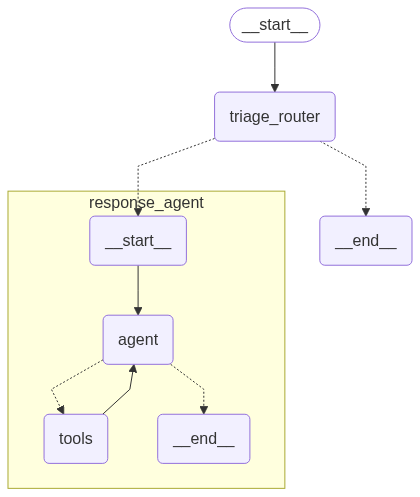

In [74]:
# Visualizando a arquitetura do modelo. 

display(Image(assistant_agent.get_graph(xray=True).draw_mermaid_png()))

### Interagindo com o modelo na nova arquitetura

In [ ]:
message_input = {
    "author": "CS Lewis",
    "to": "Sigmund Freud",
    "subject": "Preciso que me faça um brifing sobre um artigo que precisa publicar na segunda feira, cujo tema é sobre psicoterapia nos tempos da IA generativa",
    "email_thread": """
Caro senhor Sigmund Freud, asar de nos encontrarmos num zeitgeist mórbido com a Alemanhã e seus aliados nos atacando, temo que a questão psicológica não deve ser apenas
pensada nos efeitos da guerra na psiquê humana, mas sobretudo como - o que chamam - de inteligência artificial pode representar para ela também. Os meninos de Oxford, como 
Alan Turing estão conseguindo zeitos dignos de nota, utilizando modelos estatísticos para predizer um token posterior em função 
"""
}
